# Bank Transactions — EDA & Preprocessing (Corrected)

**Corrected pipeline order:**
1. Load → compute customer stats on raw data
2. Deduplicate
3. Standardize column names
4. Handle missing values
5. Type conversion
6. Fix inconsistencies (mode, not drop)
7. Fix locations → extract temporal features → age
8. Outlier decision (documented)
9. Encode categoricals
10. Normalize ALL numeric features
11. Feature selection on full feature set
12. Export

## 1. Libraries & Settings

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

def default_setting_for_dataframe():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 0)
    np.random.seed(42)

default_setting_for_dataframe()

## 2. Load Raw Data

In [2]:
DATA_PATH = '../data/raw/bank_transactions.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDtypes:\n', df.dtypes)
print('\nFirst 5 rows:\n', df.head())

Shape: (1048567, 9)

Columns: ['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)']

Dtypes:
 TransactionID                  str
CustomerID                     str
CustomerDOB                    str
CustGender                     str
CustLocation                   str
CustAccountBalance         float64
TransactionDate                str
TransactionTime              int64
TransactionAmount (INR)    float64
dtype: object

First 5 rows:
   TransactionID CustomerID CustomerDOB CustGender CustLocation  \
0            T1   C5841053     10/1/94          F   JAMSHEDPUR   
1            T2   C2142763      4/4/57          M      JHAJJAR   
2            T3   C4417068    26/11/96          F       MUMBAI   
3            T4   C5342380     14/9/73          F       MUMBAI   
4            T5   C9031234     24/3/88          F  NAVI MUMBAI   

   CustAccountBalance TransactionDate  TransactionTime

## 3. Compute Customer-Level Stats on RAW Data

> **Why here:** customer_freq and spending stats must be computed before any row drops.
> If computed after the consistency drop, ~33% of rows are already gone and multi-transaction
> customers are mostly removed — making customer_freq near-constant and useless.

In [3]:
customer_stats = df.groupby('CustomerID').agg(
    customer_freq=('TransactionID', 'count'),
    avg_txn_amount=('TransactionAmount (INR)', 'mean'),
    total_txn_amount=('TransactionAmount (INR)', 'sum')
).reset_index()

print('Customer stats shape:', customer_stats.shape)
print('\ncustomer_freq distribution:')
print(customer_stats['customer_freq'].value_counts().head(10))
print('\nStats:')
print(customer_stats.describe())

Customer stats shape: (884265, 4)

customer_freq distribution:
customer_freq
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64

Stats:
       customer_freq  avg_txn_amount  total_txn_amount
count  884265.000000    8.842650e+05      8.842650e+05
mean        1.185806    1.574781e+03      1.866856e+03
std         0.450683    6.443050e+03      7.207210e+03
min         1.000000    0.000000e+00      0.000000e+00
25%         1.000000    1.920000e+02      2.000000e+02
50%         1.000000    5.000000e+02      5.368000e+02
75%         1.000000    1.248000e+03      1.500000e+03
max         6.000000    1.560035e+06      1.560035e+06


## 4. Remove Duplicates

In [4]:
def checking_for_duplicates(df):
    duplicates_count = df.duplicated(subset=None, keep='first').sum()
    print(f'Number of duplicates: {duplicates_count}')
    print(f'Shape before: {df.shape}')
    df = df.drop_duplicates()
    print(f'Shape after: {df.shape}')
    return df

df = checking_for_duplicates(df)

Number of duplicates: 0
Shape before: (1048567, 9)
Shape after: (1048567, 9)


## 5. Standardize Column Names

In [5]:
def standardize_column_names(df):
    def to_snake_case(col):
        col_new = re.sub(r'([a-z])([A-Z])', r'\1_\2', col)
        col_new = re.sub(r'\s+', '_', col_new)
        col_new = re.sub(r'[^\w]', '', col_new)
        return col_new.lower()

    old_cols = df.columns.tolist()
    new_cols = [to_snake_case(col) for col in old_cols]
    df.columns = new_cols

    for old, new in zip(old_cols, new_cols):
        if old != new:
            print(f"Renamed: '{old}' -> '{new}'")
    return df

df = standardize_column_names(df)

# Standardize customer_stats column name to match
customer_stats = customer_stats.rename(columns={'CustomerID': 'customer_id'})
print('\nFinal columns:', df.columns.tolist())

Renamed: 'TransactionID' -> 'transaction_id'
Renamed: 'CustomerID' -> 'customer_id'
Renamed: 'CustomerDOB' -> 'customer_dob'
Renamed: 'CustGender' -> 'cust_gender'
Renamed: 'CustLocation' -> 'cust_location'
Renamed: 'CustAccountBalance' -> 'cust_account_balance'
Renamed: 'TransactionDate' -> 'transaction_date'
Renamed: 'TransactionTime' -> 'transaction_time'
Renamed: 'TransactionAmount (INR)' -> 'transaction_amount_inr'

Final columns: ['transaction_id', 'customer_id', 'customer_dob', 'cust_gender', 'cust_location', 'cust_account_balance', 'transaction_date', 'transaction_time', 'transaction_amount_inr']


## 6. Handle Missing Values

> Missing rate is very small (<0.5% for all columns) — dropping is appropriate.
> Dropping is done BEFORE the consistency check so we don't remove
> rows that are only inconsistent because one side has a null.

In [6]:
def missing_values_report(df):
    total = df.shape[0]
    missing = df.isnull().sum()
    pct = missing / total * 100
    report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct.round(2)})
    print(report[report['missing_count'] > 0])
    return report

print('Before drop:')
missing_values_report(df)

df = df.dropna()
print(f'\nShape after dropna: {df.shape}')

Before drop:
                      missing_count  missing_pct
customer_dob                   3397         0.32
cust_gender                    1100         0.10
cust_location                   151         0.01
cust_account_balance           2369         0.23

Shape after dropna: (1041614, 9)


## 7. Type Conversion

In [7]:
# IDs as string
df['transaction_id'] = df['transaction_id'].astype(str)
df['customer_id'] = df['customer_id'].astype(str)

# Parse dates — dayfirst=True for DD/MM/YYYY format
df['customer_dob'] = pd.to_datetime(
    df['customer_dob'], errors='coerce', dayfirst=True
)
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'], errors='coerce', dayfirst=True
)

# Fix 2-digit year parsing — future dates are actually 1900s
df['customer_dob'] = df['customer_dob'].apply(
    lambda x: x - pd.DateOffset(years=100) if pd.notna(x) and x > pd.Timestamp.today() else x
)

# TransactionTime: HHMMSS integer -> extract hour directly
def count_invalid_time_patterns(df, column):
    col_str = df[column].astype(str).str.zfill(6)
    invalid = col_str.apply(lambda x: x[2] in '6789' or x[4] in '6789')
    print(f'Invalid time values: {invalid.sum()}')

count_invalid_time_patterns(df, 'transaction_time')

# Extract hour before converting to time object
df['hour'] = df['transaction_time'].astype(str).str.zfill(6).str[:2].astype(int)

# Convert to clean time object (strips the 1900-01-01 artifact)
def convert_numbers_to_time(df, column):
    def fix_time_format(x):
        s = f'{int(x):06d}'
        time_str = f'{s[:2]}:{s[2:4]}:{s[4:]}'
        return pd.to_datetime(time_str, format='%H:%M:%S').time()
    df[column] = df[column].apply(fix_time_format)
    print("'transaction_time' converted to time object (no 1900-01-01 prefix)")
    return df

df = convert_numbers_to_time(df, 'transaction_time')

# Numeric columns
df['cust_account_balance'] = pd.to_numeric(df['cust_account_balance'], errors='coerce')
df['transaction_amount_inr'] = pd.to_numeric(df['transaction_amount_inr'], errors='coerce')

print('\nDtypes after conversion:')
print(df.dtypes)

Invalid time values: 0
'transaction_time' converted to time object (no 1900-01-01 prefix)

Dtypes after conversion:
transaction_id                       str
customer_id                          str
customer_dob              datetime64[us]
cust_gender                          str
cust_location                        str
cust_account_balance             float64
transaction_date          datetime64[us]
transaction_time                  object
transaction_amount_inr           float64
hour                               int64
dtype: object


## 8. Check Uniqueness

In [8]:
def uniqueness_of_column(df, column):
    is_unique = df[column].is_unique
    status = 'All unique' if is_unique else 'Contains duplicates'
    print(f"'{column}': {status}")

uniqueness_of_column(df, 'transaction_id')

# customer_id should NOT be unique (multiple transactions per customer)
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Total rows: {df.shape[0]}")

'transaction_id': All unique
Unique customers: 879358
Total rows: 1041614


## 9. Drop inconsistent KYC records (DOB/gender — imputation not permitted)

- Banking domain: DOB and gender are KYC-verified fields.
- Inconsistent records cannot be corrected statistically —
- they indicate identity corruption, system migration errors, or fraud.
- Dropping is the correct decision. Data loss is documented below.

In [9]:
def consistency_of_rows(df, id_col, *cols):
    inconsistent = df.groupby(id_col)[list(cols)].nunique()
    inconsistent_ids = inconsistent[(inconsistent > 1).any(axis=1)].index

    affected_rows = df[df[id_col].isin(inconsistent_ids)].shape[0]
    print(f"Customers with inconsistent KYC records: {len(inconsistent_ids):,}")
    print(f"Rows removed: {affected_rows:,} ({100 * affected_rows / len(df):.1f}% of data)")
    print("Reason: DOB/gender are KYC fields — statistical imputation is not permitted.")
    print("Mining conclusions reflect customers with clean, verified identity records only.")

    df = df[~df[id_col].isin(inconsistent_ids)]
    print(f"\nShape after drop: {df.shape}")
    return df

print(f'Shape before: {df.shape}')
df = consistency_of_rows(df, 'customer_id', 'customer_dob', 'cust_gender')

Shape before: (1041614, 10)
Customers with inconsistent KYC records: 140,711
Rows removed: 301,715 (29.0% of data)
Reason: DOB/gender are KYC fields — statistical imputation is not permitted.
Mining conclusions reflect customers with clean, verified identity records only.

Shape after drop: (739899, 10)


## 10. Gender Summary

In [10]:
def summarize_column(df, column):
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print(f"\nValue counts in '{column}':")
    print(df[column].value_counts())
    print(f"\nMissing values: {df[column].isnull().sum()}")

summarize_column(df, 'cust_gender')

# Filter to only M/F (single 'T' entry is negligible)
df = df[df['cust_gender'].isin(['M', 'F'])]
print(f'\nShape after filtering to M/F: {df.shape}')

Unique values in 'cust_gender':
<StringArray>
['F', 'M', 'T']
Length: 3, dtype: str

Value counts in 'cust_gender':
cust_gender
M    540772
F    199126
T         1
Name: count, dtype: int64

Missing values: 0

Shape after filtering to M/F: (739898, 10)


## 11. Fix Location — Merge Delhi/New Delhi

> Must happen BEFORE top_locations grouping and OHE.
> Otherwise both DELHI and NEW DELHI get their own OHE columns
> splitting 155K transactions' signal across two columns.

In [11]:
# Merge before any grouping
df['cust_location'] = df['cust_location'].replace('NEW DELHI', 'DELHI')

print('Top 15 locations after merge:')
print(df['cust_location'].value_counts().head(15))

Top 15 locations after merge:
cust_location
DELHI          109558
MUMBAI          72329
BANGALORE       57729
GURGAON         52606
NOIDA           23200
CHENNAI         21239
PUNE            17967
HYDERABAD       16377
THANE           15140
KOLKATA         13996
GHAZIABAD       11237
NAVI MUMBAI      9258
AHMEDABAD        8667
FARIDABAD        7971
JAIPUR           6999
Name: count, dtype: int64


## 12. Compute Age

> Using elapsed days // 365 instead of year subtraction.
> Year subtraction counts a full year even if the birthday hasn't occurred yet,
> causing off-by-1 errors at age group boundaries.

In [12]:
# Drop rows where dates are unparseable
df = df.dropna(subset=['customer_dob', 'transaction_date'])

# Correct age calculation using elapsed days
df['age'] = (df['transaction_date'] - df['customer_dob']).dt.days // 365

print('Age stats:')
print(df['age'].describe())
print(f"\nAges < 0: {(df['age'] < 0).sum()}")
print(f"Ages > 100: {(df['age'] > 100).sum()}")

# Remove unrealistic ages
df = df[(df['age'] >= 0) & (df['age'] <= 100)]
print(f'\nShape after age filter: {df.shape}')

Age stats:
count    739898.000000
mean         40.875503
std          43.045887
min         -10.000000
25%          25.000000
50%          29.000000
75%          36.000000
max         216.000000
Name: age, dtype: float64

Ages < 0: 37
Ages > 100: 40600

Shape after age filter: (699261, 11)


## 13. Extract Temporal Features

> Must happen BEFORE transaction_date is dropped.
> Day-of-week and weekend flag are important for transaction rate mining.

In [13]:
df['transaction_day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Mon, 6=Sun
df['transaction_month'] = df['transaction_date'].dt.month
df['is_weekend'] = (df['transaction_date'].dt.dayofweek >= 5).astype(int)

# Time period classification from hour
def time_period(hour):
    if 4 <= hour < 8:   return 'Early Morning (04-08)'
    elif 8 <= hour < 12:  return 'Morning (08-12)'
    elif 12 <= hour < 16: return 'Midday/Afternoon (12-16)'
    elif 16 <= hour < 20: return 'Evening (16-20)'
    elif 20 <= hour < 24: return 'Night (20-00)'
    else: return 'Late Night (00-04)'

df['transaction_time_category'] = df['hour'].apply(time_period)

categories = ['Late Night (00-04)', 'Early Morning (04-08)', 'Morning (08-12)',
              'Midday/Afternoon (12-16)', 'Evening (16-20)', 'Night (20-00)']
df['transaction_time_category'] = pd.Categorical(
    df['transaction_time_category'], categories=categories, ordered=True
)

print('Temporal features added:')
print(df[['transaction_day_of_week','transaction_month','is_weekend','transaction_time_category']].head())

Temporal features added:
   transaction_day_of_week  transaction_month  is_weekend  \
0                        1                  8           0   
1                        1                  8           0   
2                        1                  8           0   
4                        1                  8           0   
5                        1                  8           0   

  transaction_time_category  
0  Midday/Afternoon (12-16)  
1  Midday/Afternoon (12-16)  
2  Midday/Afternoon (12-16)  
4           Evening (16-20)  
5           Evening (16-20)  


## 14. Merge Customer Stats

In [14]:
df = df.merge(customer_stats, on='customer_id', how='left')

print('customer_freq distribution after merge (from RAW data):')
print(df['customer_freq'].value_counts().head(10))
print('\nStats:')
print(df['customer_freq'].describe())

customer_freq distribution after merge (from RAW data):
customer_freq
1    695980
2      3261
3        20
Name: count, dtype: int64

Stats:
count    699261.000000
mean          1.004721
std           0.068961
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: customer_freq, dtype: float64


## 15. EDA — Distributions

--- cust_account_balance ---
Data Type: float64
Missing: 0 (0.00%)
Unique: 138579

Summary:
count    6.992610e+05
mean     1.053671e+05
std      8.086395e+05
min      0.000000e+00
25%      4.575650e+03
50%      1.601141e+04
75%      5.375908e+04
max      1.150355e+08
Name: cust_account_balance, dtype: float64


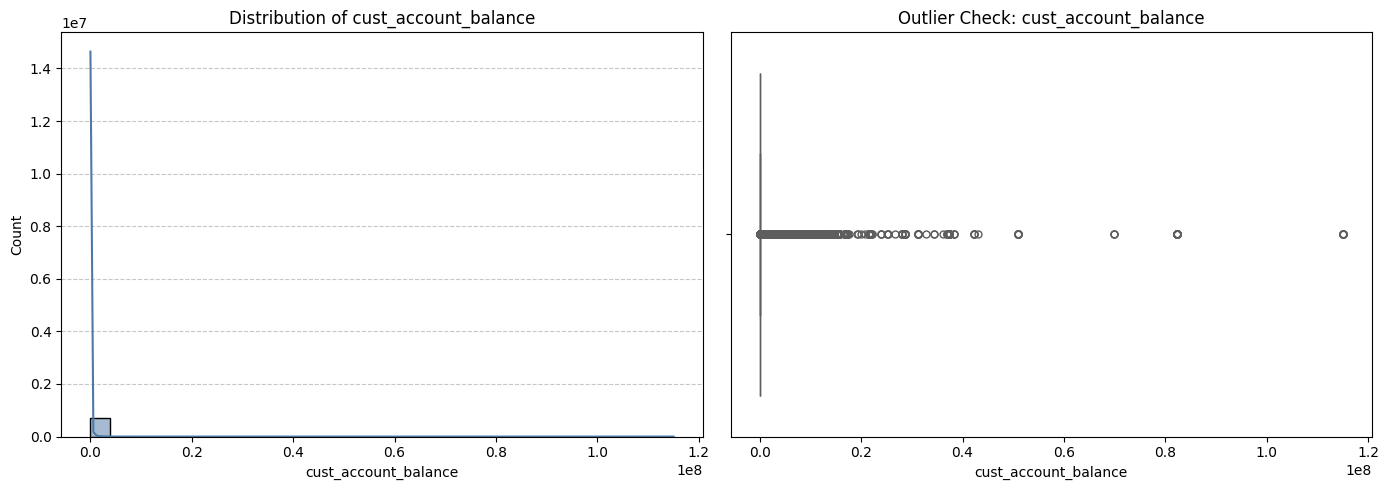

--- transaction_amount_inr ---
Data Type: float64
Missing: 0 (0.00%)
Unique: 68243

Summary:
count    6.992610e+05
mean     1.454472e+03
std      6.381163e+03
min      0.000000e+00
25%      1.520000e+02
50%      4.310000e+02
75%      1.126800e+03
max      1.560035e+06
Name: transaction_amount_inr, dtype: float64


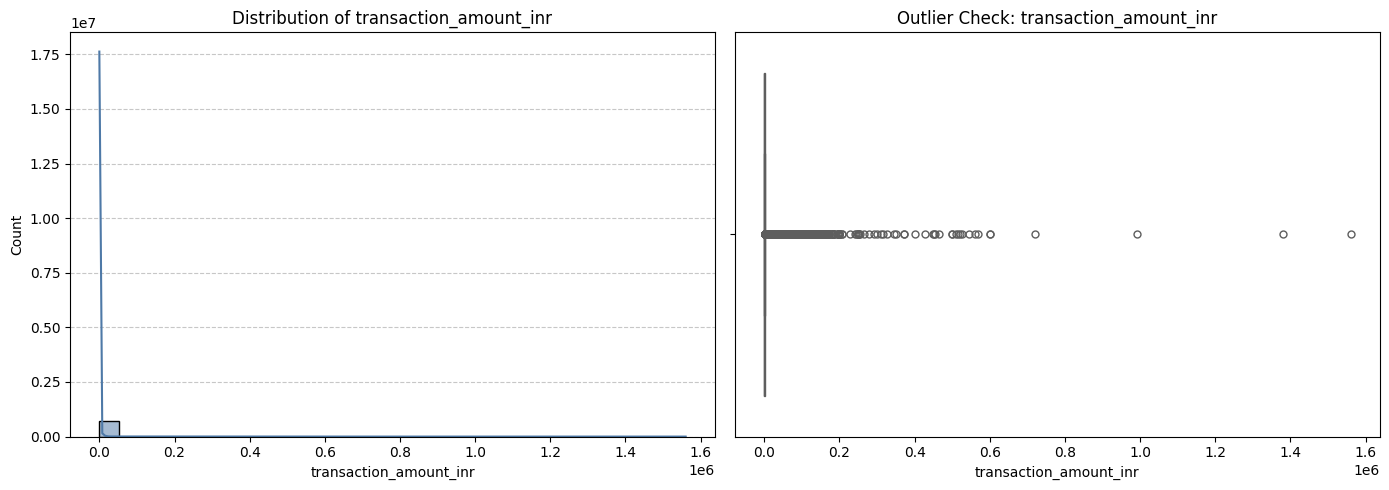

--- age ---
Data Type: int64
Missing: 0 (0.00%)
Unique: 90

Summary:
count    699261.000000
mean         30.710012
std           8.747473
min           0.000000
25%          25.000000
50%          28.000000
75%          34.000000
max          89.000000
Name: age, dtype: float64


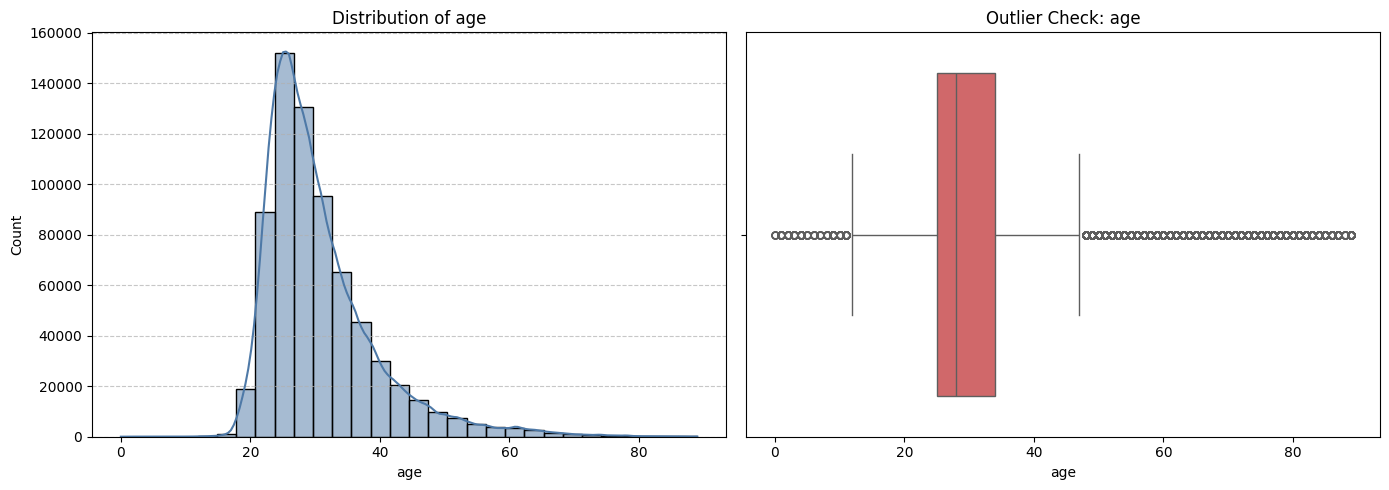

--- customer_freq ---
Data Type: int64
Missing: 0 (0.00%)
Unique: 3

Summary:
count    699261.000000
mean          1.004721
std           0.068961
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: customer_freq, dtype: float64


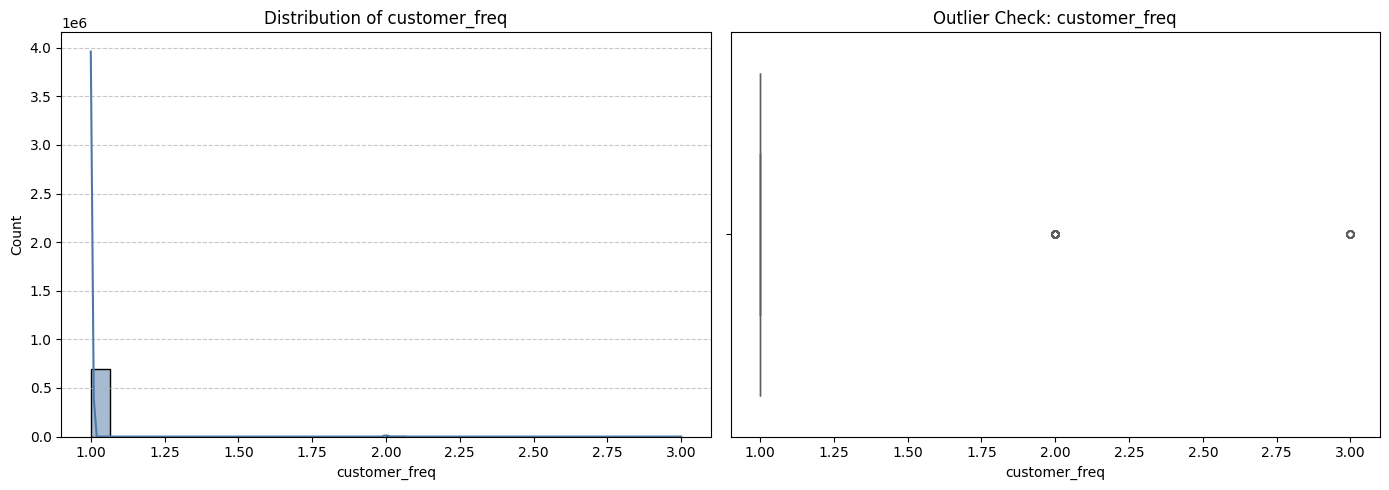

--- avg_txn_amount ---
Data Type: float64
Missing: 0 (0.00%)
Unique: 68672

Summary:
count    6.992610e+05
mean     1.455894e+03
std      6.380712e+03
min      0.000000e+00
25%      1.530000e+02
50%      4.335000e+02
75%      1.130000e+03
max      1.560035e+06
Name: avg_txn_amount, dtype: float64


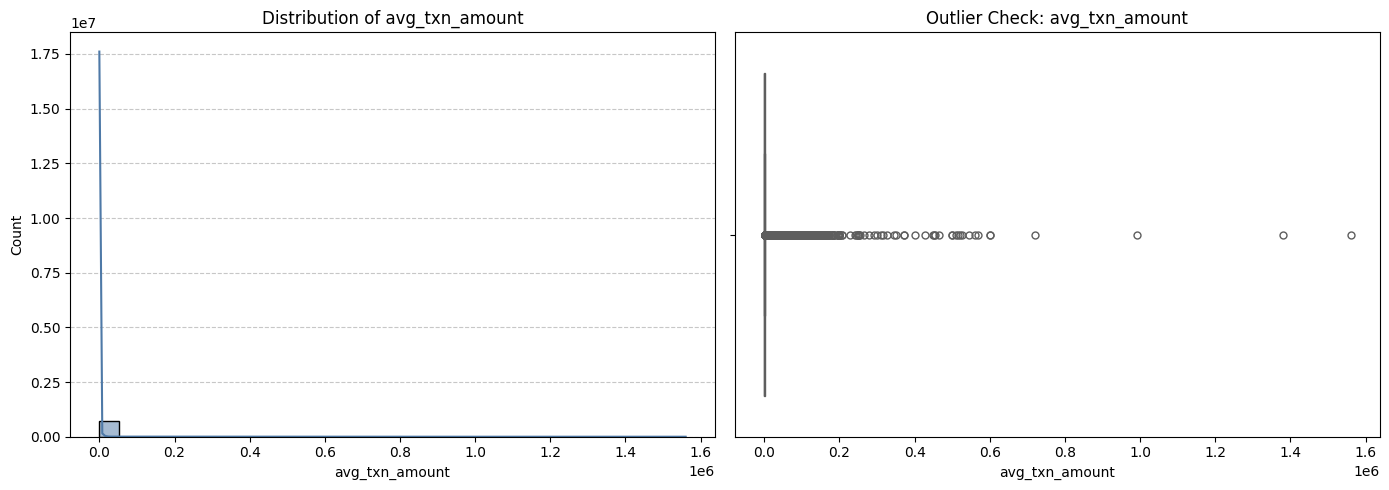

--- cust_gender ---
Data Type: str
Missing: 0 (0.00%)
Unique: 2

Value Counts (Top 10):
cust_gender
M    505715
F    193546
Name: count, dtype: int64


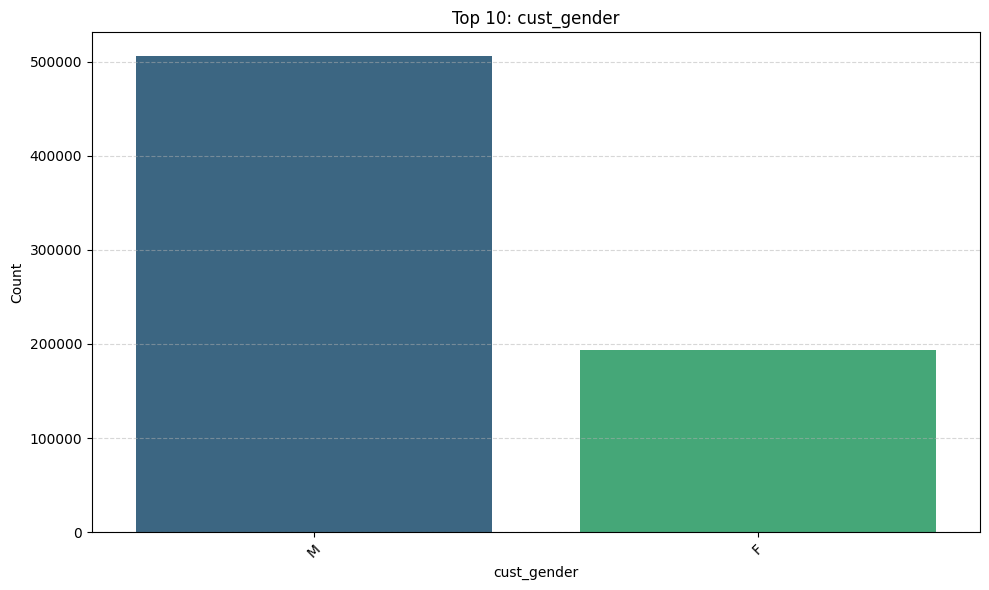

--- cust_location ---
Data Type: str
Missing: 0 (0.00%)
Unique: 7571

Value Counts (Top 10):
cust_location
DELHI        101605
MUMBAI        69208
BANGALORE     55119
GURGAON       50362
NOIDA         22512
CHENNAI       19571
PUNE          17132
HYDERABAD     15541
THANE         14861
KOLKATA       13419
Name: count, dtype: int64


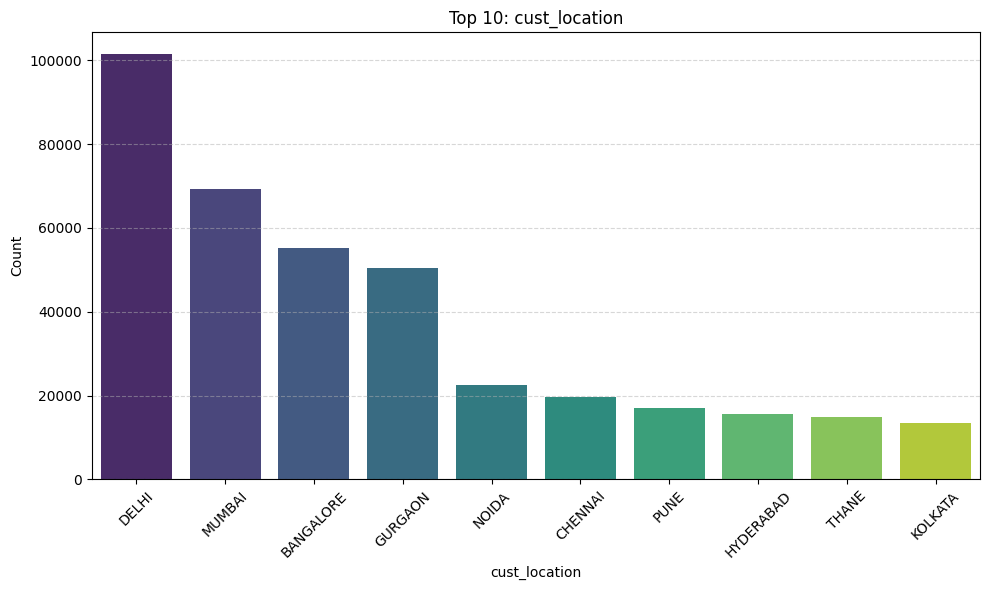

--- transaction_time_category ---
Data Type: category
Missing: 0 (0.00%)
Unique: 6

Value Counts (Top 10):
transaction_time_category
Evening (16-20)             205472
Night (20-00)               177359
Midday/Afternoon (12-16)    170033
Morning (08-12)             100042
Late Night (00-04)           24688
Early Morning (04-08)        21667
Name: count, dtype: int64


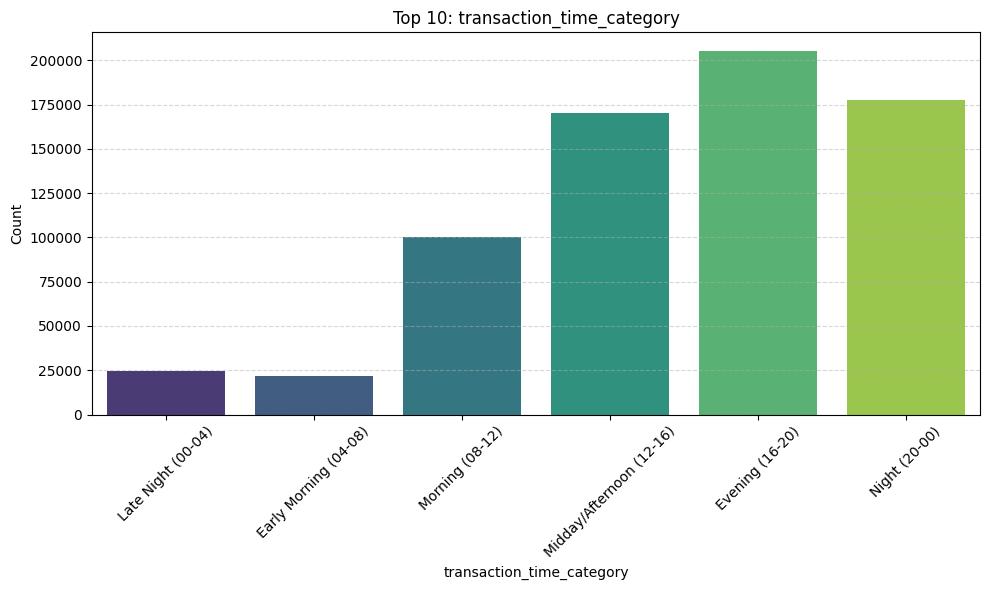

In [15]:
def check_distribution(df, column_name):
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return

    print(f'--- {column_name} ---')
    print(f'Data Type: {df[column_name].dtype}')
    print(f'Missing: {df[column_name].isnull().sum()} ({df[column_name].isnull().mean()*100:.2f}%)')
    print(f'Unique: {df[column_name].nunique()}')

    if pd.api.types.is_numeric_dtype(df[column_name]):
        print('\nSummary:')
        print(df[column_name].describe())
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.histplot(df[column_name], kde=True, color='#4e79a7', bins=30, ax=axes[0])
        axes[0].set_title(f'Distribution of {column_name}')
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        sns.boxplot(x=df[column_name], color='#e15759', fliersize=5, ax=axes[1])
        axes[1].set_title(f'Outlier Check: {column_name}')
        plt.tight_layout()
        plt.show()
    else:
        counts = df[column_name].value_counts().head(10)
        print('\nValue Counts (Top 10):')
        print(counts)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.index, y=counts.values, palette='viridis')
        plt.title(f'Top 10: {column_name}')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

for col in ['cust_account_balance', 'transaction_amount_inr', 'age', 'customer_freq',
            'avg_txn_amount', 'cust_gender', 'cust_location', 'transaction_time_category']:
    check_distribution(df, col)

## 16. Outlier Decision (Documented)

> IQR analysis shows ~13% of account balances and ~11% of transaction amounts
> exceed the upper fence. Outliers are RETAINED because:
> - This is unsupervised data mining, not regression — there is no target to distort
> - Yeo-Johnson normalization compresses extreme values adequately
> - High-balance customers are a meaningful segment, not noise
> - Removing them would bias the clustering away from HNI/corporate accounts
>
> Decision: retain outliers, apply Yeo-Johnson to normalize scale.

In [16]:
for col in ['cust_account_balance', 'transaction_amount_inr']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers):,} outliers ({100*len(outliers)/len(df):.1f}%) — RETAINED')

cust_account_balance: 92,745 outliers (13.3%) — RETAINED
transaction_amount_inr: 74,828 outliers (10.7%) — RETAINED


## 17. Demographic EDA

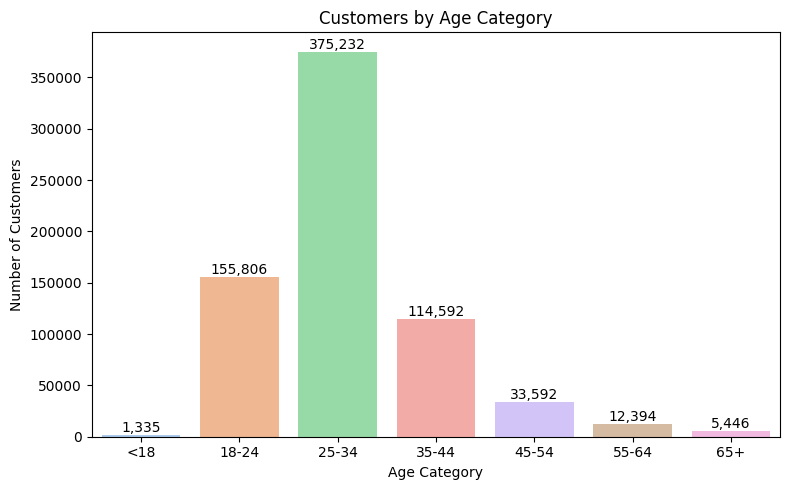

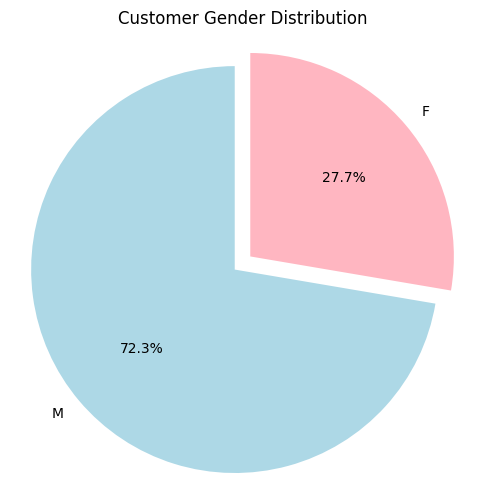

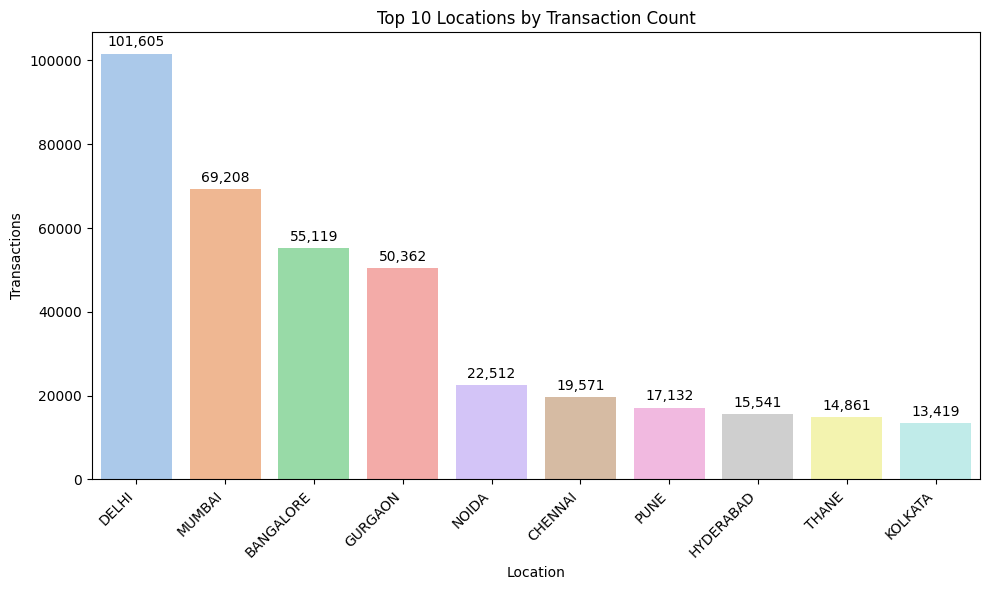

In [17]:
# Age distribution
bins   = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_counts = df.groupby('age_category', observed=True)['customer_id'].nunique()
plt.figure(figsize=(8, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='pastel')
for i, v in enumerate(age_counts.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.title('Customers by Age Category')
plt.tight_layout()
plt.show()

# Gender pie chart
gender_counts = df['cust_gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'lightpink'], startangle=90, explode=(0.05, 0.05))
plt.title('Customer Gender Distribution')
plt.axis('equal')
plt.show()

# Top 10 locations
location_counts = df['cust_location'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette='pastel')
for i, v in enumerate(location_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', va='bottom')
plt.xlabel('Location')
plt.ylabel('Transactions')
plt.title('Top 10 Locations by Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 18. Spending Category EDA

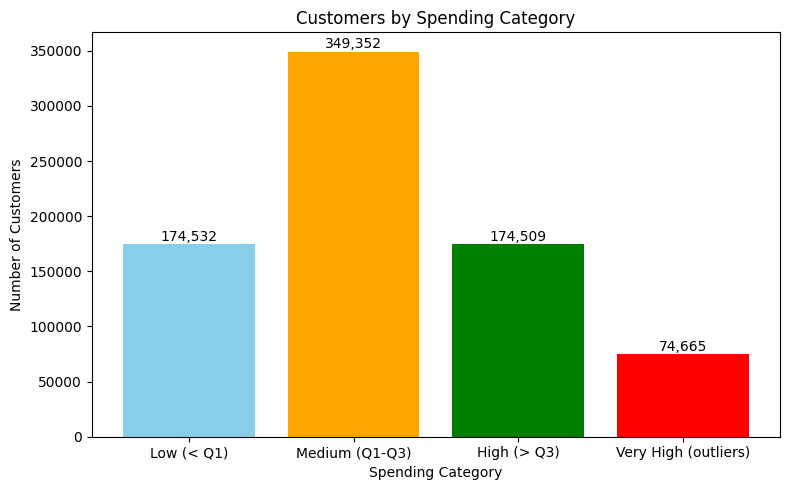

      Spending Category  Number of Customers  Mean Transaction Value
0            Low (< Q1)               174532                   69.43
1        Medium (Q1-Q3)               349352                  492.77
2           High (> Q3)               174509                 4766.73
3  Very High (outliers)                74665                 8845.49


In [18]:
total  = df.groupby('customer_id')['transaction_amount_inr'].sum()
average = df.groupby('customer_id')['transaction_amount_inr'].mean()

Q1, Q3 = total.quantile(0.25), total.quantile(0.75)
IQR = Q3 - Q1
outliers_mask = (total < Q1 - 1.5 * IQR) | (total > Q3 + 1.5 * IQR)

low_spenders      = (total < Q1).sum()
mid_spenders      = ((total >= Q1) & (total <= Q3)).sum()
high_spenders     = (total > Q3).sum()
outlier_count     = outliers_mask.sum()

categories = ['Low (< Q1)', 'Medium (Q1-Q3)', 'High (> Q3)', 'Very High (outliers)']
values     = [low_spenders, mid_spenders, high_spenders, outlier_count]
colors     = ['skyblue', 'orange', 'green', 'red']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, values, color=colors)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,}', ha='center', va='bottom')
plt.xlabel('Spending Category')
plt.ylabel('Number of Customers')
plt.title('Customers by Spending Category')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Spending Category': categories,
    'Number of Customers': values,
    'Mean Transaction Value': [
        round(average[total < Q1].mean(), 2),
        round(average[(total >= Q1) & (total <= Q3)].mean(), 2),
        round(average[total > Q3].mean(), 2),
        round(average[outliers_mask].mean(), 2)
    ]
})
print(summary)

## 19. Encoding — Categoricals

### Gender: Binary
### Age: Ordinal (preserves order)
### Location: Top 15 + OTHER grouping, then OHE with drop_first
### Time: OHE with drop_first

> drop_first=True on both OHE groups avoids the dummy variable trap
> (perfect multicollinearity that breaks linear models and inflates
> feature weight in distance-based clustering).

In [19]:
# Binary gender encoding
df['gender_encoded'] = df['cust_gender'].map({'M': 0, 'F': 1})

# Ordinal age encoding
age_map = {'<18': 0, '18-24': 1, '25-34': 2, '35-44': 3, '45-54': 4, '55-64': 5, '65+': 6}
df['age_ordinal'] = df['age_category'].map(age_map)

# Location grouping — note Delhi already merged in step 11
top_locations = df['cust_location'].value_counts().nlargest(15).index
df['location_grouped'] = df['cust_location'].apply(
    lambda x: x if x in top_locations else 'OTHER'
)

print('Location groups:')
print(df['location_grouped'].value_counts())

Location groups:
location_grouped
OTHER          278825
DELHI          101605
MUMBAI          69208
BANGALORE       55119
GURGAON         50362
NOIDA           22512
CHENNAI         19571
PUNE            17132
HYDERABAD       15541
THANE           14861
KOLKATA         13419
GHAZIABAD       10404
NAVI MUMBAI      8558
AHMEDABAD        8019
FARIDABAD        7564
JAIPUR           6561
Name: count, dtype: int64


## 20. Drop Raw Columns, Apply OHE

In [20]:
cols_to_drop = [
    'transaction_id',         # identifier only
    'customer_dob', # age already extracted
    'transaction_date',       # temporal features already extracted
    'transaction_time',       # time_category already extracted
    'cust_location',          # location_grouped replaces this
    'cust_gender',            # gender_encoded replaces this
    'age_category',           # age_ordinal replaces this
    'age',                    # age_ordinal replaces this
    'hour',                   # transaction_time_category replaces this
]
# Note: customer_id is NOT in cols_to_drop — kept as joinable key

# Apply OHE with drop_first=True to avoid dummy trap
df_final = pd.get_dummies(
    df,
    columns=['transaction_time_category', 'location_grouped'],
    prefix=['time', 'loc'],
    drop_first=True
)

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# Cast OHE bool columns to int
ohe_cols = [c for c in df_final.columns if c.startswith(('time_', 'loc_'))]
df_final[ohe_cols] = df_final[ohe_cols].astype(int)

print('Columns after encoding:')
print(df_final.columns.tolist())
print(f'\nShape: {df_final.shape}')

Columns after encoding:
['customer_id', 'cust_account_balance', 'transaction_amount_inr', 'transaction_day_of_week', 'transaction_month', 'is_weekend', 'customer_freq', 'avg_txn_amount', 'total_txn_amount', 'gender_encoded', 'age_ordinal', 'time_Early Morning (04-08)', 'time_Morning (08-12)', 'time_Midday/Afternoon (12-16)', 'time_Evening (16-20)', 'time_Night (20-00)', 'loc_BANGALORE', 'loc_CHENNAI', 'loc_DELHI', 'loc_FARIDABAD', 'loc_GHAZIABAD', 'loc_GURGAON', 'loc_HYDERABAD', 'loc_JAIPUR', 'loc_KOLKATA', 'loc_MUMBAI', 'loc_NAVI MUMBAI', 'loc_NOIDA', 'loc_OTHER', 'loc_PUNE', 'loc_THANE']

Shape: (699261, 31)


## 21. Normalize ALL Numeric Features

> Corrected: normalize AFTER encoding and AFTER all features are assembled.
> Previous version only normalized balance and amount — leaving customer_freq,
> avg_txn_amount, total_txn_amount, age_ordinal, day_of_week, month on
> different raw scales, which would dominate distance calculations in clustering.
>
> Yeo-Johnson is used because it handles zeros and near-zero values.
> customer_id is excluded. OHE columns (0/1) are excluded — already on unit scale.

In [21]:
# All numeric features that need normalization (exclude id, OHE cols, binary cols)
cols_to_normalize = [
    'cust_account_balance',
    'transaction_amount_inr',
    'customer_freq',
    'avg_txn_amount',
    'total_txn_amount',
    'age_ordinal',
    'transaction_day_of_week',
    'transaction_month',
]

# Only normalize columns that are present in df_final
cols_to_normalize = [c for c in cols_to_normalize if c in df_final.columns]

pt = PowerTransformer(method='yeo-johnson')
normalized = pt.fit_transform(df_final[cols_to_normalize])
normalized_df = pd.DataFrame(normalized, columns=[c + '_normalized' for c in cols_to_normalize],
                             index=df_final.index)

# Drop raw numeric cols, add normalized versions
df_final = df_final.drop(columns=cols_to_normalize)
df_final = pd.concat([df_final, normalized_df], axis=1)

# is_weekend is already binary 0/1 — no normalization needed
print('Columns after normalization:')
print(df_final.columns.tolist())
print(f'\nShape: {df_final.shape}')

Columns after normalization:
['customer_id', 'is_weekend', 'gender_encoded', 'time_Early Morning (04-08)', 'time_Morning (08-12)', 'time_Midday/Afternoon (12-16)', 'time_Evening (16-20)', 'time_Night (20-00)', 'loc_BANGALORE', 'loc_CHENNAI', 'loc_DELHI', 'loc_FARIDABAD', 'loc_GHAZIABAD', 'loc_GURGAON', 'loc_HYDERABAD', 'loc_JAIPUR', 'loc_KOLKATA', 'loc_MUMBAI', 'loc_NAVI MUMBAI', 'loc_NOIDA', 'loc_OTHER', 'loc_PUNE', 'loc_THANE', 'cust_account_balance_normalized', 'transaction_amount_inr_normalized', 'customer_freq_normalized', 'avg_txn_amount_normalized', 'total_txn_amount_normalized', 'age_ordinal_normalized', 'transaction_day_of_week_normalized', 'transaction_month_normalized']

Shape: (699261, 31)


## 22. Feature Selection

> Corrected: run selection on the FULL feature set (normalized numerics + OHE)
> Previous version only evaluated 4 numerical columns and never checked OHE columns.
>
> Two methods used:
> 1. Shannon entropy — information content per feature
> 2. Variance — near-zero variance features add noise, not signal

Features going into selection:
['is_weekend', 'gender_encoded', 'time_Early Morning (04-08)', 'time_Morning (08-12)', 'time_Midday/Afternoon (12-16)', 'time_Evening (16-20)', 'time_Night (20-00)', 'loc_BANGALORE', 'loc_CHENNAI', 'loc_DELHI', 'loc_FARIDABAD', 'loc_GHAZIABAD', 'loc_GURGAON', 'loc_HYDERABAD', 'loc_JAIPUR', 'loc_KOLKATA', 'loc_MUMBAI', 'loc_NAVI MUMBAI', 'loc_NOIDA', 'loc_OTHER', 'loc_PUNE', 'loc_THANE', 'cust_account_balance_normalized', 'transaction_amount_inr_normalized', 'customer_freq_normalized', 'avg_txn_amount_normalized', 'total_txn_amount_normalized', 'age_ordinal_normalized', 'transaction_day_of_week_normalized', 'transaction_month_normalized']


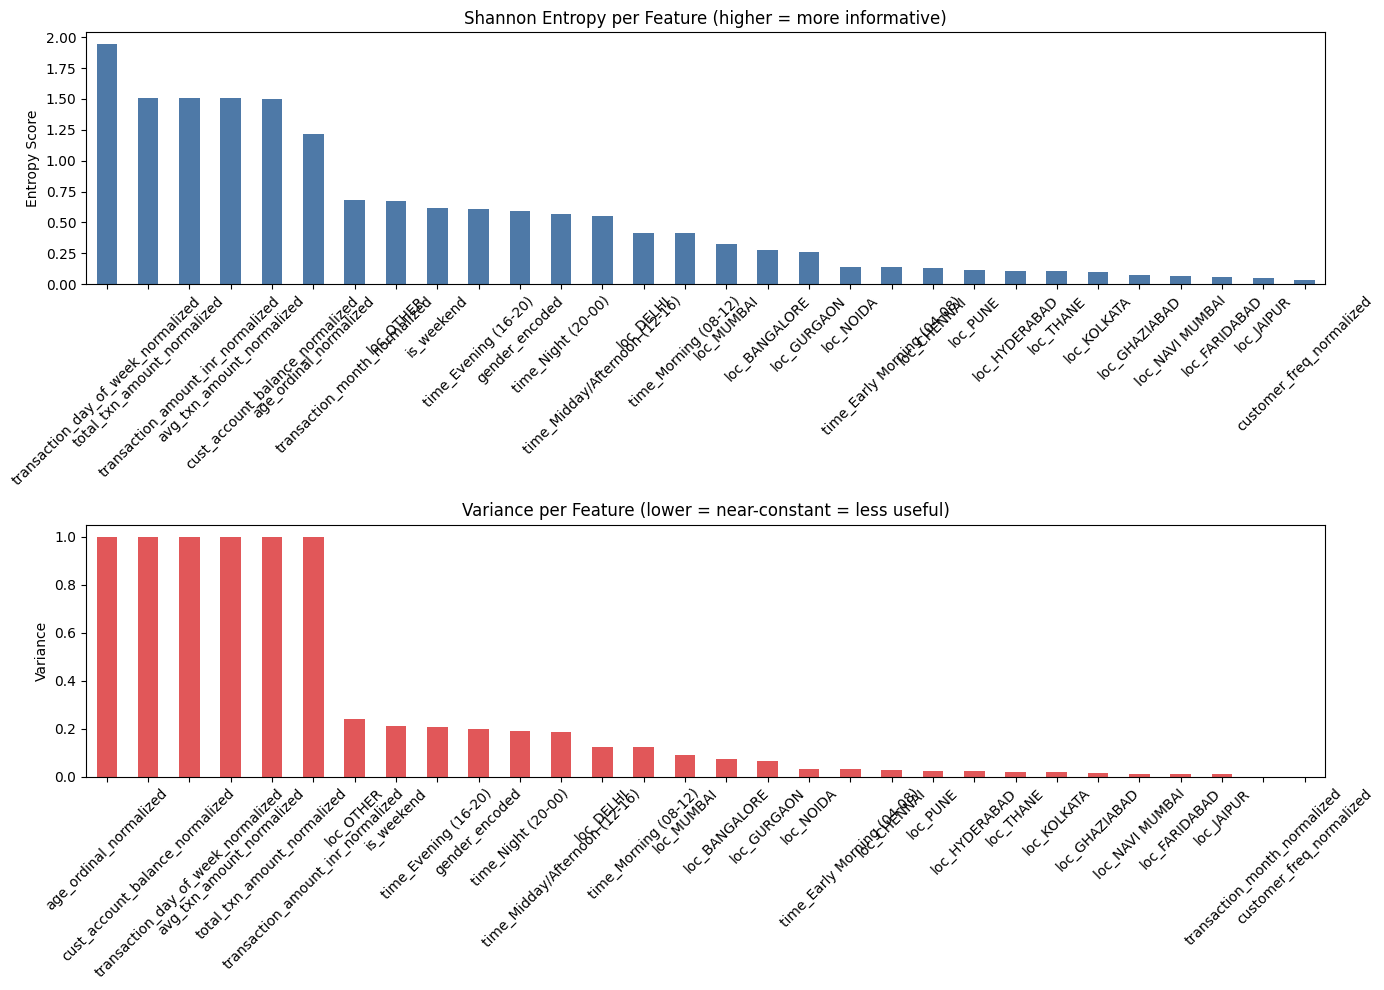

--- Entropy Rankings ---
transaction_day_of_week_normalized    1.942852
total_txn_amount_normalized           1.511086
transaction_amount_inr_normalized     1.510380
avg_txn_amount_normalized             1.507394
cust_account_balance_normalized       1.500122
age_ordinal_normalized                1.216579
transaction_month_normalized          0.682208
loc_OTHER                             0.672498
is_weekend                            0.617429
time_Evening (16-20)                  0.605556
gender_encoded                        0.589893
time_Night (20-00)                    0.566296
time_Midday/Afternoon (12-16)         0.554696
loc_DELHI                             0.414475
time_Morning (08-12)                  0.410494
loc_MUMBAI                            0.322821
loc_BANGALORE                         0.275889
loc_GURGAON                           0.258837
loc_NOIDA                             0.142288
time_Early Morning (04-08)            0.138152
loc_CHENNAI                        

In [22]:
# Exclude customer_id AND any non-numeric columns (datetime, object, etc.)
feature_cols = [
    c for c in df_final.columns
    if c != 'customer_id'
    and pd.api.types.is_numeric_dtype(df_final[c])
]

print("Features going into selection:")
print(feature_cols)

df_features = df_final[feature_cols]

# --- Shannon Entropy ---
def calculate_entropy(data, bins=10):
    hist, _ = np.histogram(data, bins=bins, density=True)
    hist = hist[hist > 0]
    return entropy(hist)

entropy_scores = {col: calculate_entropy(df_features[col]) for col in feature_cols}
entropy_results = pd.Series(entropy_scores).sort_values(ascending=False)

# --- Variance ---
variance_scores = df_features.var().sort_values(ascending=False)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

entropy_results.plot(kind='bar', color='#4e79a7', ax=axes[0])
axes[0].set_title('Shannon Entropy per Feature (higher = more informative)')
axes[0].set_ylabel('Entropy Score')
axes[0].tick_params(axis='x', rotation=45)

variance_scores.plot(kind='bar', color='#e15759', ax=axes[1])
axes[1].set_title('Variance per Feature (lower = near-constant = less useful)')
axes[1].set_ylabel('Variance')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('--- Entropy Rankings ---')
print(entropy_results)
print('\n--- Variance Rankings ---')
print(variance_scores)

## 23. Correlation Matrix (Numerical Features Only)

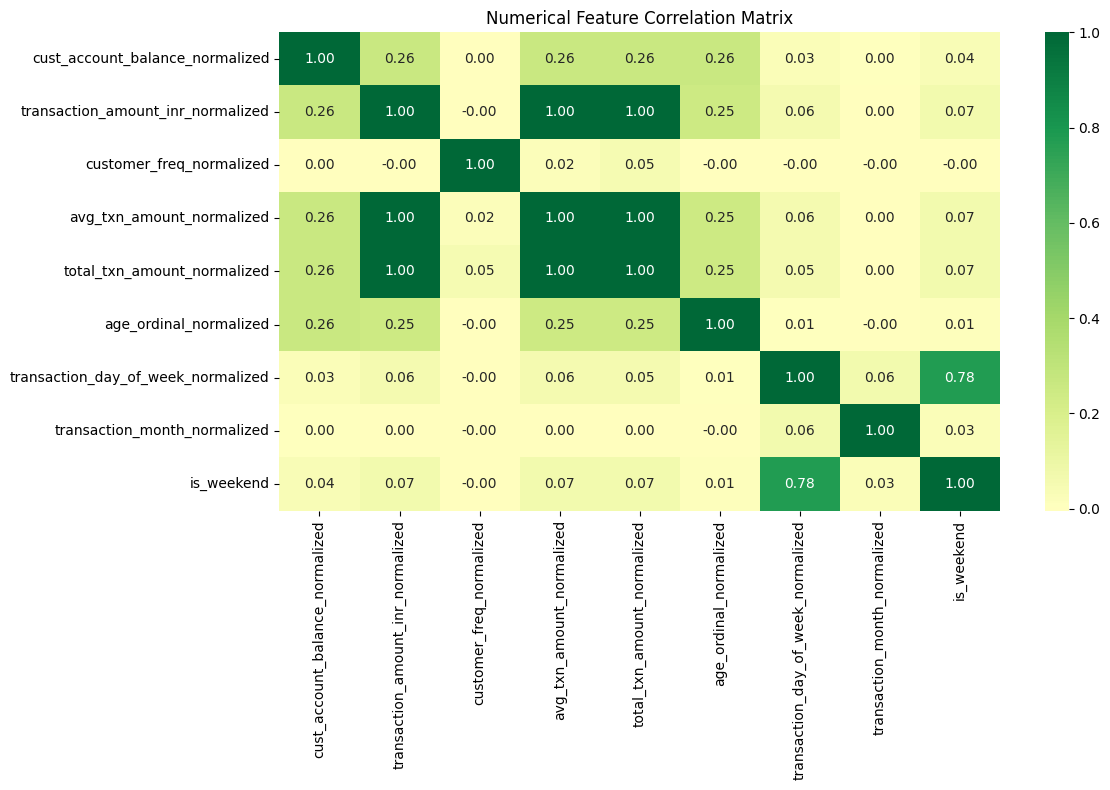

In [23]:
normalized_cols = [c for c in df_final.columns if c.endswith('_normalized')]
df_num = df_final[normalized_cols + ['is_weekend']]

plt.figure(figsize=(12, 8))
sns.heatmap(df_num.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [24]:
# transaction_amount_inr, avg_txn_amount, total_txn_amount are perfectly 
# correlated (r=1.00) because most customers have only 1 transaction.
# Keeping all three triple-counts the amount dimension in clustering.
# Keep transaction_amount_inr as it represents the actual transaction value.
# avg and total become meaningful again if customer_freq improves in future data.

df_final = df_final.drop(columns=[
    'avg_txn_amount_normalized',
    'total_txn_amount_normalized'
], errors='ignore')

In [25]:
# is_weekend and transaction_day_of_week are correlated at 0.78
# because is_weekend is derived from day_of_week.
# is_weekend is more interpretable for mining (binary behavioral split).
# transaction_day_of_week is redundant given is_weekend is already present.

df_final = df_final.drop(columns=[
    'transaction_day_of_week_normalized'
], errors='ignore')

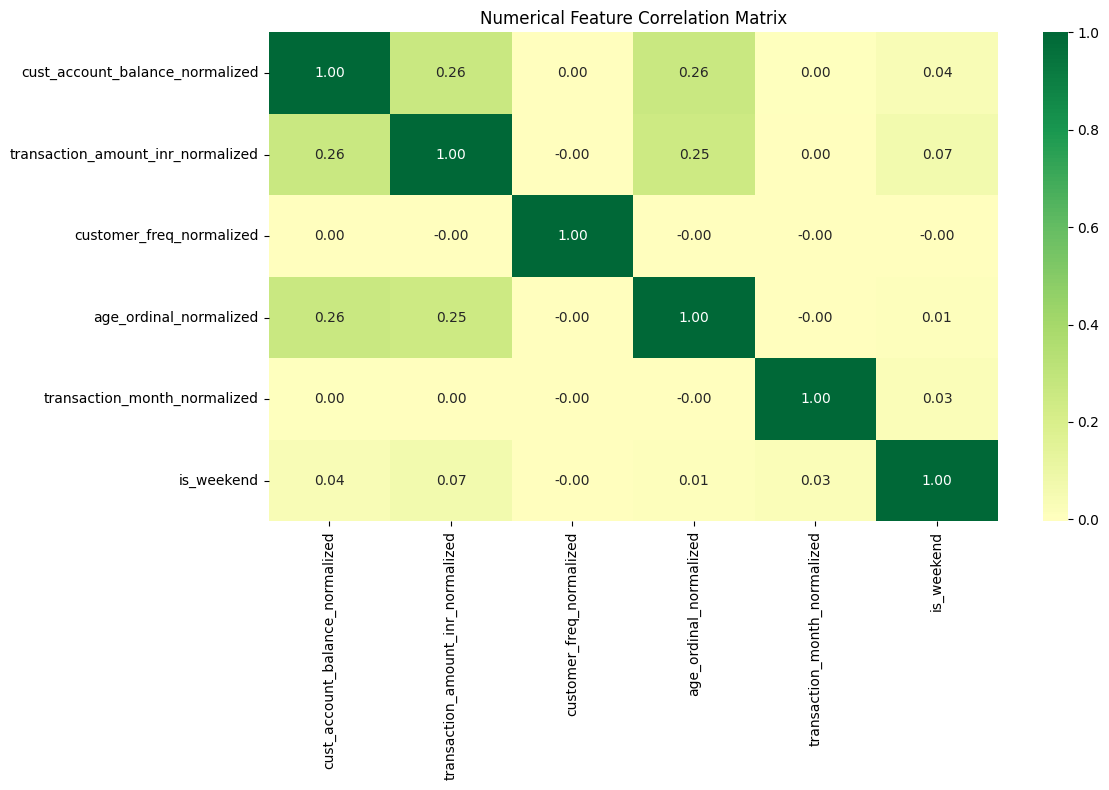

In [26]:
normalized_cols = [c for c in df_final.columns if c.endswith('_normalized')]
df_num = df_final[normalized_cols + ['is_weekend']]

plt.figure(figsize=(12, 8))
sns.heatmap(df_num.corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Feature Selection Decision

Entropy and variance analysis: no features dropped.
- All analytical dimensions retained: location, time, demographics,
  transaction behavior, transaction rate
- loc_OTHER already covers rare cities not in top 15
- customer_freq_normalized retained as core transaction rate feature
  despite low variance (artifact of KYC consistency drop, not a signal problem)

Correlation analysis (Cell 23): two redundancies found and resolved:
- avg_txn_amount_normalized + total_txn_amount_normalized dropped (r=1.00 with transaction_amount_inr)
- transaction_day_of_week_normalized dropped (r=0.78 with is_weekend)

## 24. Final Check & Export

In [27]:
print('=== FINAL DATASET SUMMARY ===')
print(f'Shape: {df_final.shape}')
print(f'\nMissing values:')
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])
print(f'\nDtypes:')
print(df_final.dtypes)
print(f'\nFirst 5 rows:')
print(df_final.head())

# Verify no ghost index column
assert 'Unnamed: 0' not in df_final.columns, 'Ghost index column found!'
# Verify customer_id present
assert 'customer_id' in df_final.columns, 'customer_id missing!'
# Verify no bool OHE
bool_cols = [c for c in df_final.columns if df_final[c].dtype == bool]
assert len(bool_cols) == 0, f'Bool columns found: {bool_cols}'

print('\nAll assertions passed. Exporting clean.csv...')

# index=False prevents ghost Unnamed: 0 column
df_final.to_csv('../data/processed/clean.csv', index=False)
print('Exported to ../data/processed/clean.csv')

=== FINAL DATASET SUMMARY ===
Shape: (699261, 28)

Missing values:
Series([], dtype: int64)

Dtypes:
customer_id                              str
is_weekend                             int64
gender_encoded                         int64
time_Early Morning (04-08)             int64
time_Morning (08-12)                   int64
time_Midday/Afternoon (12-16)          int64
time_Evening (16-20)                   int64
time_Night (20-00)                     int64
loc_BANGALORE                          int64
loc_CHENNAI                            int64
loc_DELHI                              int64
loc_FARIDABAD                          int64
loc_GHAZIABAD                          int64
loc_GURGAON                            int64
loc_HYDERABAD                          int64
loc_JAIPUR                             int64
loc_KOLKATA                            int64
loc_MUMBAI                             int64
loc_NAVI MUMBAI                        int64
loc_NOIDA                              int64